C:\Users\laank\AppData\Local\Temp\ipykernel_22288\597796406.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


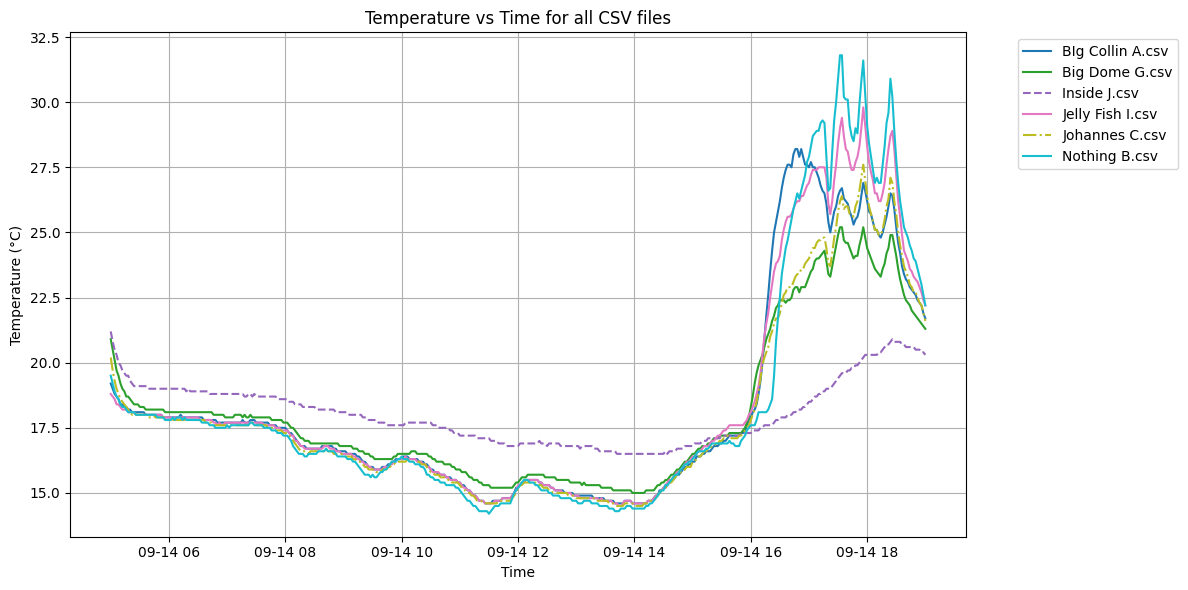

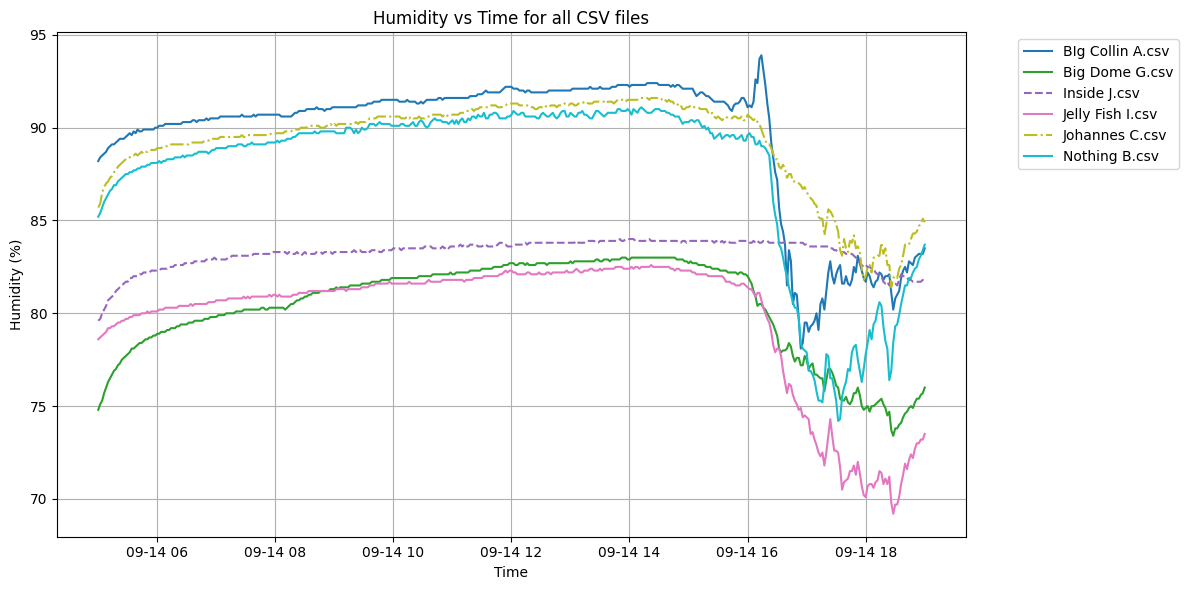

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

# csv_files = glob.glob("*.csv")

csv_files = ['BIg Collin A.csv', 'Big Dome G.csv', 'Inside J.csv', 'Jelly Fish I.csv', 'Johannes C.csv', 'Nothing B.csv']

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",", 
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep= ',',
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


0      22.710
1      22.537
2      22.357
3      22.180
4      22.030
        ...  
847    23.920
848    23.983
849    24.093
850    24.187
851    24.297
Name: Temperature[°C], Length: 852, dtype: float64


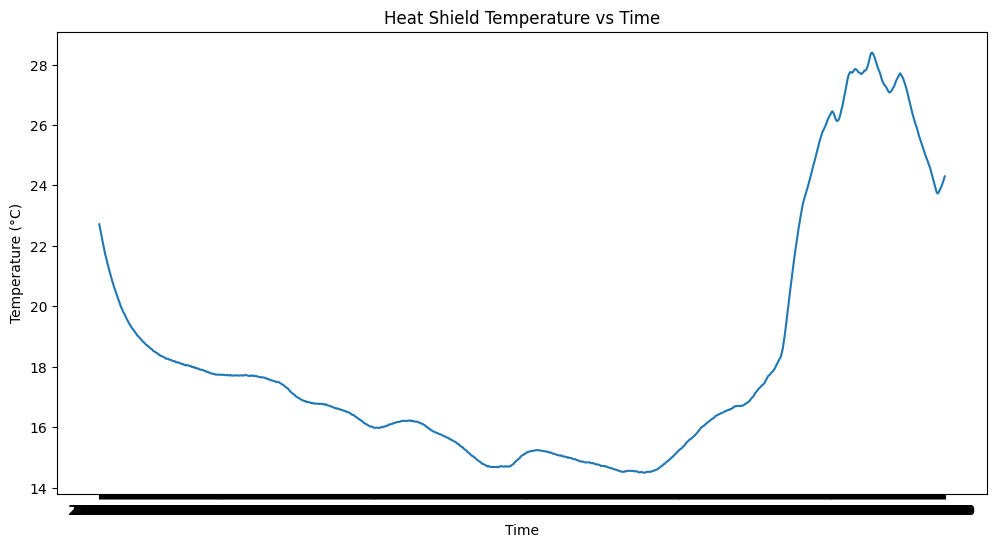

In [14]:
sh = pd.read_csv('divertest1409.csv')
sh.head()

print(sh['Temperature[°C]'])

plt.figure(figsize=(12,6))
plt.plot(sh['time'], sh['Temperature[°C]'])
plt.xlabel("Time")  
plt.ylabel("Temperature (°C)")
plt.title("Heat Shield Temperature vs Time")
plt.show()

C:\Users\laank\AppData\Local\Temp\ipykernel_22288\2448118320.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


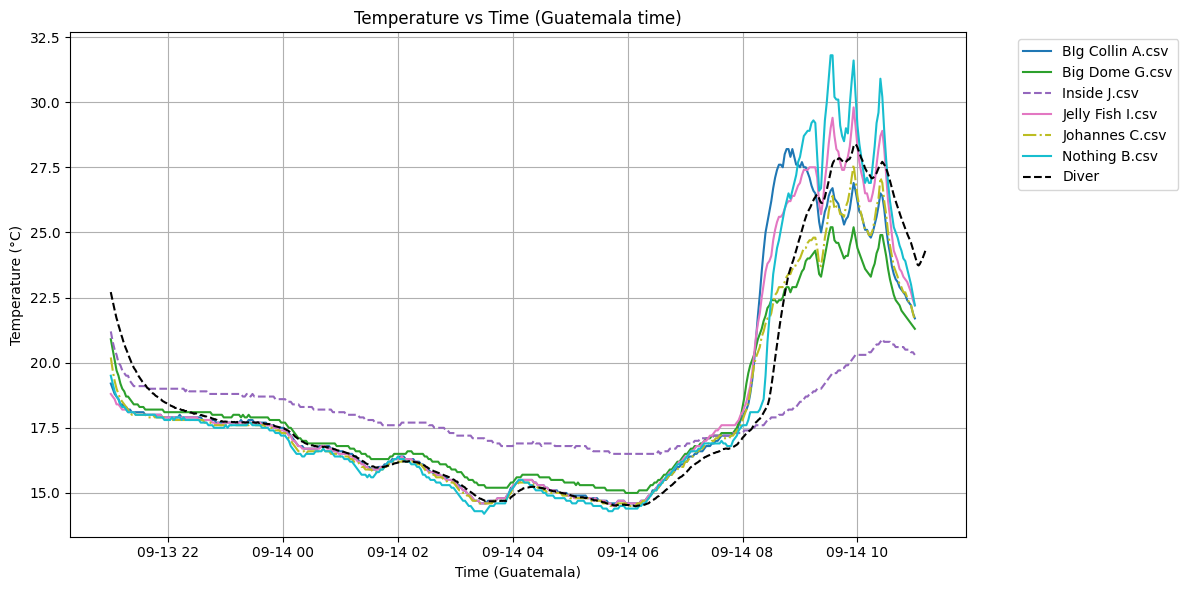

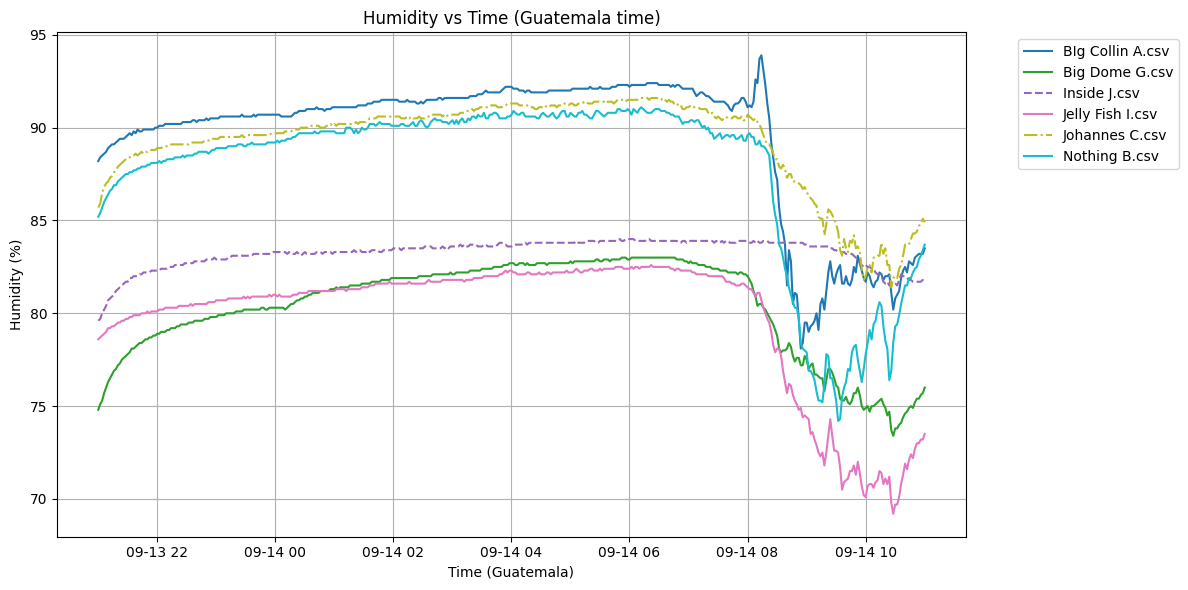

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import date, timedelta

# --- CSVs for logtags ---
csv_files = [
    'BIg Collin A.csv',
    'Big Dome G.csv',
    'Inside J.csv',
    'Jelly Fish I.csv',
    'Johannes C.csv',
    'Nothing B.csv'
]

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--',
    4: '-.',
    6: ':'
}

# --- Read diver data (Guatemala time) ---
diver_file = "divertest1409.csv"
sh = pd.read_csv(diver_file, sep=",", decimal=".")

# Start date of diver measurement (set manually or parse from filename)
real_date = date(2025, 9, 13)

# Build datetime from date + time
sh["Datetime"] = pd.to_datetime(
    str(real_date) + " " + sh["time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

# Fix midnight rollover (if times wrap past 00:00, shift to next day)
for i in range(1, len(sh)):
    if sh.loc[i, "Datetime"] < sh.loc[i - 1, "Datetime"]:
        sh.loc[i:, "Datetime"] += timedelta(days=1)


# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12, 6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name,
        sep=",",
        decimal=".",
        usecols=[0, 1, 2, 3, 4],
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    # Logtags: Dutch time → convert to Guatemalan time (subtract 8h)
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        errors="coerce"
    ) - timedelta(hours=8)

    style = special_styles.get(i, "-")
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

# Diver data (already in Guatemala time)
plt.plot(sh["Datetime"], sh["Temperature[°C]"], label="Diver", color="black", linestyle="--")

plt.xlabel("Time (Guatemala)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time (Guatemala time)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12, 6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name,
        sep=",",
        decimal=".",
        usecols=[0, 1, 2, 3, 4],
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str) + " " + df["Time"].astype(str),
        errors="coerce"
    ) - timedelta(hours=8)

    style = special_styles.get(i, "-")
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time (Guatemala)")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time (Guatemala time)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid()
plt.tight_layout()
plt.show()
